# ITI5149 2024
# Assessment 2: Customer Churn Prediction


**Group 1:**
- Eddy (Student ID: 33495068)
- Ibra Ufauwid (Student ID: 19252994)
- Robby Lysander Aurelio (Student ID: 32889356)


**Programming Language:** R (v4.2.3) in Jupyter Notebook using Visual Studio Code (v1.92.0)

**R Libraries used:**
- tidyverse
- gridExtra
- caret
- themis
- rpart
- rpart.plot

## Table of Contents

1. [Introduction](#sec_1)
2. [Exploratory Data Analysis](#sec_2)
3. [Methodology](#sec_3)
4. [Model Selection](#sec_4)
5. [Model Development](#sec_5)
6. [Results and discussion](#sec_6)
7. [Prediction](#sec_7)
8. [Conclusion](#sec_8)
9. [References](#sec_9)

## 1. Introduction <a class="anchor" id="sec_1"></a>

**Customer churn** can be described as the phenomenon where customers stopped using services of a company. In the banking industry, it refers to the loss of customers who close their accounts, switch to another bank, or stop using specific services. Moreover, customer churn can negatively impact a bank's reputation, as high churn rates often indicate **underlying issues** within the bank itself. Therefore, understanding and analyzing customer churn pattern is crucial for banks, as it helps them to **identify reasons** behind customer departure and **develop strategies** to retain them. Often referred to as customer attrition, this issue poses a significant challenge faced by banks and financial institutions, making it a key focus area for a sutainable long-term success. That is why, this study is conducted.

The main question that we want to answer with this study is **which users are the most likely to churn?** In addition, we also would like to know **which variables that have the most impact** on user deciding to churn. By identifying which customers are more likely to churn and what are the important factors affecting that decision, we can develop an action plan to prevent a high churn rate.

### 1.1. Dataset

To reach the goal of the study, we use a dataset that contains **7,000 historical customer records**, and each customer has **10 attributes** (columns), including an identifier (`ID`) and a label called `Y`, which will be used as the target column, that indicate whether the customer churn or not. The datasets used can be downloaded from this [link](https://drive.google.com/file/d/17v1-4M2HnYasjKNrZCLel6zc0DqJG5wP/view?usp=sharing). 

The detail about the columns can be seen in the table below:
| Column             | Description                                                                                   |
|--------------------|-----------------------------------------------------------------------------------------------|
| ID                 | Unique identifier for the data record.                                                        |
| credit_score       | Score potentially affecting customer churn; higher scores indicate lower likelihood of churn. |
| tenure             | Number of years the customer has been with the bank.                                          |
| balance            | Current account balance; higher balances suggest lower likelihood of churn.                   |
| number_of_products | Count of products purchased by the customer through the bank.                                 |
| has_credit_card    | Binary indicator (1 for yes, 0 for no) of whether the customer holds a credit card.           |
| is_active_member   | Binary indicator (1 for yes, 0 for no) of whether the customer is an active member.           |
| salary             | Customer's salary information.                                                                |
| customer_profile   | Textual description combining all the above input variables.                                  |
| Y                  | Response variable indicating whether a customer churns (1) or not (0).                        |

**Import Libraries**

In [1]:
# Load all the necessary libraries
library(tidyverse)
library(gridExtra)
library(caret)
library(themis)
library(rpart)
library(rpart.plot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.1     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift


Loading required package: recipes


Attaching package: 'recipes'


The following object is masked from 'package:stringr':

    fixed


The following object is masked from 'package:stats':

    step




**Dataset Loading**

In [2]:
# Load the dataset for training the machine learning model
df_raw <- read_csv("./A2_customer_churn_labeled.csv")

Rows: 7000 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): customer_profile
dbl (9): ID, credit_score, tenure, balance, number_of_products, has_credit_c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 1.2. Checking the Dataset

Firstly, before we use the dataset for the training purposes, we need to examine the dataset to **ensure the dataset's readiness** for the next section. In this section, we will explore and check the dataset to identify potential issues, then fix problem the data in the next section, to make sure the dataset is all aligned to our project objectives.

**Check the Structure**

In [3]:
# Evaluate dimensions
cat("The dataset has", dim(df_raw)[1], "records, each with", dim(df_raw)[2],"attributes.")

The dataset has 7000 records, each with 10 attributes.

In [4]:
# Check the first few records
head(df_raw, 5)

ID,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,customer_profile,Y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
0,585,4,0.0,2,0,1,101728.46,This customer is a 44-year-old female from Spain with a credit score of 585.0. She has been a member for 4.0 years and currently has 2.0 products with a balance of 0.0. She does not have a credit card but is an active member. Her estimated salary is 101728.4609375.,0
1,743,6,140348.6,2,1,1,163254.39,"This customer is a 32-year-old female from Germany with a credit score of 743.0. She has been a customer for 6.0 years and currently has a balance of 140348.5625. She has 2.0 products with the bank, including a credit card, and is an active member. Her estimated salary is 163254.390625.",0
2,527,10,136733.2,1,1,1,57589.29,This customer is a 41-year-old female from Germany with a credit score of 527.0. She has been a customer for 10.0 years and has a balance of 136733.234375. She has one product with the bank and has a credit card. She is an active member and her estimated salary is 57589.2890625.,0
3,732,6,98792.4,1,1,0,81491.70,"This customer is a 45-year-old female from Germany with a credit score of 732.0. She has been a customer for 6.0 years and currently has a balance of 98792.3984375. She has one product with the bank and has a credit card. However, she is not an active member. Her estimated salary is 81491.703125.",1
4,641,3,0.0,2,1,0,116466.19,"This customer is a 38-year-old female from France with a credit score of 641.0. She has been a customer for 3.0 years and currently has a balance of 0.0. She has 2.0 products with the bank, including a credit card. However, she is not an active member. Her estimated salary is 116466.1875.",0


In [5]:
# Check the variable datatype and content of the variable
str(df_raw)

spc_tbl_ [7,000 × 10] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ ID                : num [1:7000] 0 1 2 3 4 5 6 7 8 9 ...
 $ credit_score      : num [1:7000] 585 743 527 732 641 793 708 757 501 498 ...
 $ tenure            : num [1:7000] 4 6 10 6 3 3 10 6 8 4 ...
 $ balance           : num [1:7000] 0 140349 136733 98792 0 ...
 $ number_of_products: num [1:7000] 2 2 1 1 2 1 2 2 2 2 ...
 $ has_credit_card   : num [1:7000] 0 1 1 1 1 0 1 1 1 1 ...
 $ is_active_member  : num [1:7000] 1 1 1 0 0 0 1 1 0 1 ...
 $ salary            : num [1:7000] 101728 163254 57589 81492 116466 ...
 $ customer_profile  : chr [1:7000] "This customer is a 44-year-old female from Spain with a credit score of 585.0. She has been a member for 4.0 ye"| __truncated__ "This customer is a 32-year-old female from Germany with a credit score of 743.0. She has been a customer for 6."| __truncated__ "This customer is a 41-year-old female from Germany with a credit score of 527.0. She has been a customer for 10"| __truncate

We observe that some of the columns have the **incorrect datatypes**, such as `has_credit_card`, `is_active_member`, and `Y`, should be categorical columns, but is still in numeric with a numerical encoding. Therefore, we need to change the column datatype from numeric to categorical (factor) in the next section.

**Check Missing Values**

We next examine if there are any missing values in the dataset. Missing value can interfere with the the data quality, statistical analysis, data imputation, variable selection, as well as pattern discovery. Therefore, if there are missing values, proper techniques need to be applied to handle them.

In [6]:
# Check for missing values in the dataset
missing_values <- df_raw %>% summarise_all(~ sum(is.na(.)))
#print the missing values
cat("\nThe missing values for each variable: \n")
print(missing_values)


The missing values for each variable: 
# A tibble: 1 × 10
     ID credit_score tenure balance number_of_products has_credit_card
  <int>        <int>  <int>   <int>              <int>           <int>
1     0            0      0       0                  0               0
# ℹ 4 more variables: is_active_member <int>, salary <int>,
#   customer_profile <int>, Y <int>


Note that there are **no missing values** in the dataset

**Check for Invalid Data**

Checking for invalid data is crucial because it ensures accurate analysis, reliable insights, and informed decision-making. Invalid data can lead to inaccurate results, misguide decisions, and compromise the integrity of the dataset. For numerical data, we can print out the range and determine whether it makes sense or not. On the other hand, for categorical data, we can check whether the categories are consistent based on specification documents or not. Lastly, because the customer profile is text data, then we will treat it differently later on.

In [7]:
# Print the unique values of each  variable
for (col in names(df_raw)) {
  # Skip the `customer_profile` column
  if (col == 'customer_profile') {
    next
  } else if (col %in% c('ID', 'credit_score', 'tenure', 'balance', 'number_of_products', 'salary')) {
    # Print out the range
    cat("\nThe values in variable", col, "are: ", min(df_raw[col]), '-' , max(df_raw[col]))
  } else{
    # Convert the unique values to a single string separated by commas
    unique_values <- paste(unique(df_raw[[col]]), collapse = ", ")
    cat("\nThe values in variable", col, "are:", unique_values)}
}


The values in variable ID are:  0 - 6999
The values in variable credit_score are:  350 - 850
The values in variable tenure are:  0 - 10
The values in variable balance are:  0 - 222267.6
The values in variable number_of_products are:  1 - 4
The values in variable has_credit_card are: 0, 1
The values in variable is_active_member are: 1, 0
The values in variable salary are:  11.58 - 199992.5
The values in variable Y are: 0, 1

Note that there is **no invalid data** in the dataset, all values are within the specification.

**Check the Customer Profile column**

Because we're unable to see the values for the customer profile, here we print the first 10 column to see the pattern of the customer profile column

In [8]:
# Printing the 10 first value for the customer profile column
head(df_raw$customer_profile, 10)

[1] "This customer is a 44-year-old female from Spain with a credit score of 585.0. She has been a member for 4.0 years and currently has 2.0 products with a balance of 0.0. She does not have a credit card but is an active member. Her estimated salary is 101728.4609375."                                
 [2] "This customer is a 32-year-old female from Germany with a credit score of 743.0. She has been a customer for 6.0 years and currently has a balance of 140348.5625. She has 2.0 products with the bank, including a credit card, and is an active member. Her estimated salary is 163254.390625."          
 [3] "This customer is a 41-year-old female from Germany with a credit score of 527.0. She has been a customer for 10.0 years and has a balance of 136733.234375. She has one product with the bank and has a credit card. She is an active member and her estimated salary is 57589.2890625."                  
 [4] "This customer is a 45-year-old female from Germany with a credit score of 732.0. She has been a customer for 6.0 years and currently has a balance of 98792.3984375. She has one product with the bank and has a credit card. However, she is not an active member. Her estimated salary is 81491.703125."
 [5] "This customer is a 38-year-old female from France with a credit score of 641.0. She has been a customer for 3.0 years and currently has a balance of 0.0. She has 2.0 products with the bank, including a credit card. However, she is not an active member. Her estimated salary is 116466.1875."        
 [6] "This customer is a 39-year-old male from France with a credit score of 793.0. He has been a customer for 3.0 years and currently has a balance of 137817.515625. He has one product with the bank and does not have a credit card or active membership. His estimated salary is 83997.7890625."           
 [7] "This customer is a 32-year-old male from France with a credit score of 708.0. He has been a customer for 10.0 years and currently has a balance of 86614.0625. He has 2.0 products with the bank, including a credit card, and is an active member. His estimated salary is 172129.265625."               
 [8] "This customer is a 30-year-old male from Germany with a credit score of 757.0. He has been a customer for 6.0 years and currently has a balance of 105128.8515625. He has 2.0 products with the bank, including a credit card, and is an active member. His estimated salary is 62972.12890625."          
 [9] "This customer is a 29-year-old female from France with a credit score of 501.0. She has been a customer for 8.0 years and currently has a balance of 0.0. She has 2.0 products with the company and has a credit card. However, she is not an active member. Her estimated salary is 112664.2421875."     
[10] "This customer is a 41-year-old female from Germany with a credit score of 498.0. She has been a customer for 4.0 years and currently has a balance of 87541.0625. She has 2.0 products with the bank, including a credit card, and is an active member. Her estimated salary is 12577.2099609375."

For the above examples, note that the `customer_profile` column is just a summary from the other columns, except the information about the customer's **age, gender, and origin**. Therefore, we only need to extract those three information and then we can remove this column.

**Summary**

Here we have seen all of the columns, this is the table summarizing the variable features.

| Columns              | Definition | Values in Dataset  | Variable Type |
|------------------------|--------------------------------------------------------------------------|-----------------------------------------------------|---------------|
| ID                   | Unique identifier for the data record   | Numbers                 | Numeric       |
| credit_score   | Score potentially affecting customer churn; higher scores indicate lower likelihood of churn | Score |Numeric       |
| tenure |  Number of years the customer has been with the bank.  | Numbers   | Numeric       |
| balance                 |Current account balance; higher balances suggest lower likelihood of churn                                                  |                Numbers                                     | Numeric       |
| number_of_products    |  Count of products purchased by the customer through the bank             | Numbers     | Numeric       |
| has_credit_card              | Binary indicator (1 for yes, 0 for no) of whether the customer holds a creditcard. |1 and 0 | Numeric   |
| is_active_member    | Binary indicator (1 for yes, 0 for no) of whether the customer is an active member | 1 and 0  | Numeric  |
| salary        | Customer's salary information  | Numbers | Numeric |
| customer_profile    | Textual description combining all the above input variables. | Text Description of the customer | Character  |
| Y         | Response variable indicating whether a customer churns (1) or not (0). | 1 and 0 | Numeric|

Here we summarize the findings:
- Some columns have **incorrect datatype**, such as numeric for the categorical columns.
- Some values in the column could be confusing because they use **numerical encoding**, such as 0 for "No" and 1 for "Yes".
- The `customer_profile` column values has been investigated, we discovered that most of the information is **already provided** in the other columns, thus we just need to extract the new information.

### 1.3. Data Wrangling

Now we can start to fix the issues found in the previous section. Here we will:
- **Datatype Conversion:** convert the columns to their correct datatype.
- **Numerical Decoding:** convert the numerical encodings to their original meanings, such as "Yes" or "No".
- **Feature Extraction:** extract only the new information from the `customer_profile` column and add them to the dataset as new columns, then remove the `customer_profile` column.

In [9]:
# Wrangling the data
df <- df_raw %>%
    mutate(has_credit_card = factor(has_credit_card, levels = c(0,1), labels = c('No', 'Yes')),
           is_active_member = factor(is_active_member, levels = c(0,1), labels = c('No', 'Yes')),
           Y = factor(Y, levels = c(0,1), labels = c('Not Churn', 'Churn')),
           age = as.numeric(sub(".*\\bis an? (\\d+)-year-old.*", "\\1", customer_profile)),
           origin = factor(sub(".*\\bfrom ([A-Za-z]+).*", "\\1", customer_profile)),
           gender = factor(sub(".*\\b(male|female)\\b.*", "\\1", customer_profile), labels = c('Female', 'Male'))) %>%
    select(-Y, -customer_profile, Y)

# Making sure that the changes has taken effect
head(df)

ID,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,age,origin,gender,Y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>
0,585,4,0.0,2,No,Yes,101728.46,44,Spain,Female,Not Churn
1,743,6,140348.6,2,Yes,Yes,163254.39,32,Germany,Female,Not Churn
2,527,10,136733.2,1,Yes,Yes,57589.29,41,Germany,Female,Not Churn
3,732,6,98792.4,1,Yes,No,81491.70,45,Germany,Female,Churn
4,641,3,0.0,2,Yes,No,116466.19,38,France,Female,Not Churn
5,793,3,137817.5,1,No,No,83997.79,39,France,Male,Not Churn


Here we have the updated table that describe the columns after wrangling:


| Columns              | Definition                                                               | Values in dataset                                   | Variable Type |
|------------------------|--------------------------------------------------------------------------|-----------------------------------------------------|---------------|
| ID                   | Unique identifier for the data record                                             | Numbers                                 | Numeric       |
| credit_score                | Score potentially affecting customer churn; higher scores indicate lower likelihood of churn | Score                                            | Numeric       |
| tenure |  Number of years the customer has been with the bank.                                            | Numbers                            | Numeric       |
| balance                 |Current account balance; higher balances suggest lower likelihood of churn                                                  |                Numbers                                     | Nominal       |
| number_of_products    |  Count of products purchased by the customer through the bank             | Numbers     | Nominal       |
| has_credit_card              | Indicator of whether the customer holds a creditcard. | Yes and No | Factor|
| is_active_member    | Indicator of whether the customer is an active member.           | Yes and No | Factor       |
| salary        | Customer's salary information  | Numbers | Nominal |
| age       | The cutomer's age (in years) | Numbers | Numeric|
| origin    | The customer's country of origin | France, Germany, and Spain | Factor  |
| gender           | The customer's Gender  | Male and Female| Factor |
| Y         | Target label describing if the customer churned or not | Churn and Not Churn | Factor |

## 2. Exploratory Data Analysis<a class="anchor" id="sec_2"></a>

This part will explore the dataset using various statistical analysis to identify interesting patterns. The analysis consists of:

- **Descriptive Statistics:** summarize the central tendencies, dispersion, and shape of the distribution using descriptive statistics. Visualisations such as boxplots, histograms, bar charts, and pie charts will also be used to help with the analysis.
- **Correlation analysis:** calculate the Pearson correlation coefficient and use visualisations to reveal the relationships between several variables. This will also help to identify whether there are any co-dependencies between the predictors.

Firstly, let's start with checking the summary of the dataset

In [10]:
# First, let's check the summary of the dataset
summary(df)

       ID        credit_score       tenure          balance      
 Min.   :   0   Min.   :350.0   Min.   : 0.000   Min.   :     0  
 1st Qu.:1750   1st Qu.:585.0   1st Qu.: 3.000   1st Qu.:     0  
 Median :3500   Median :653.0   Median : 5.000   Median : 97467  
 Mean   :3500   Mean   :651.9   Mean   : 5.049   Mean   : 76990  
 3rd Qu.:5249   3rd Qu.:719.0   3rd Qu.: 8.000   3rd Qu.:127790  
 Max.   :6999   Max.   :850.0   Max.   :10.000   Max.   :222268  
 number_of_products has_credit_card is_active_member     salary         
 Min.   :1.000      No :2067        No :3392         Min.   :    11.58  
 1st Qu.:1.000      Yes:4933        Yes:3608         1st Qu.: 51193.14  
 Median :1.000                                       Median :100272.16  
 Mean   :1.532                                       Mean   :100016.92  
 3rd Qu.:2.000                                       3rd Qu.:148507.12  
 Max.   :4.000                                       Max.   :199992.48  
      age         origin   

From the summary, we can see that target variable has a class imbalance. To make it more clear to see the comparison, we can plot it using a barchart.

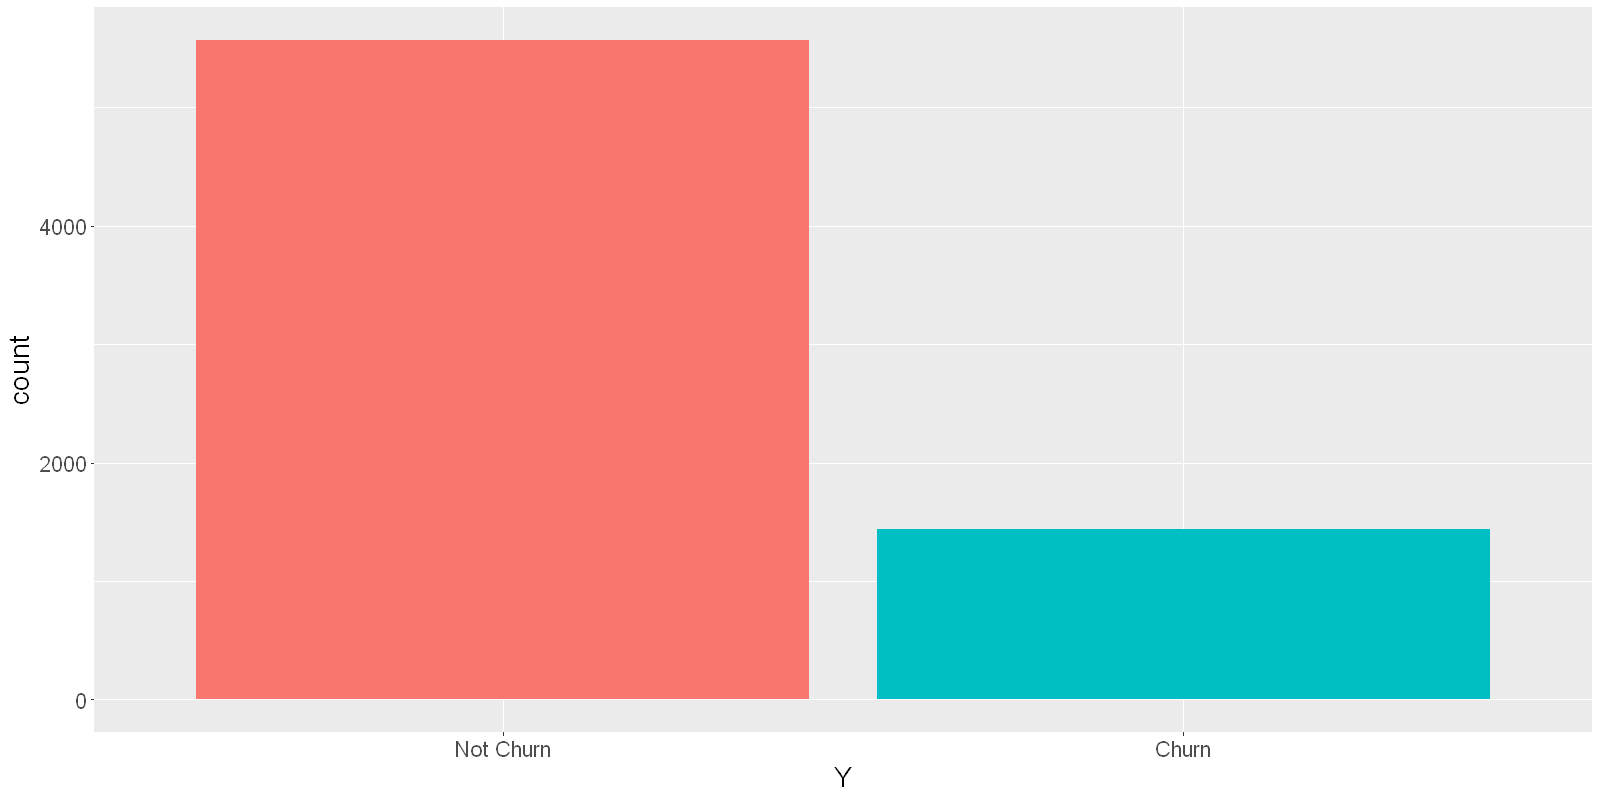

In [11]:
options(repr.plot.width = 16, repr.plot.height = 8, repr.plot.res = 100)

# Create a bar chart to see the class imbalance
ggplot(df, aes(x = Y, fill = Y)) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

From the above chart, it is clear that there is a class imbalance problem in the target variable with the "Not Churn" having the more count.

### 2.1. Exploring the Numerical Columns

Next we can start to explore the numerical data, first by visualizing it with a boxplot to see the spread of the data points. Please note that here we exclude the `number_of_products` and `tenure` columns as their values are discrete, thus it is more appropriate to explore them along with the categroical columns.

In [12]:
# Pivot the numerical variable to long form to make it easier to plot
df_long_num <- df %>%
    pivot_longer(cols = c('credit_score', 'balance', 'salary', 'age'),
                names_to = 'variable', values_to = 'value')

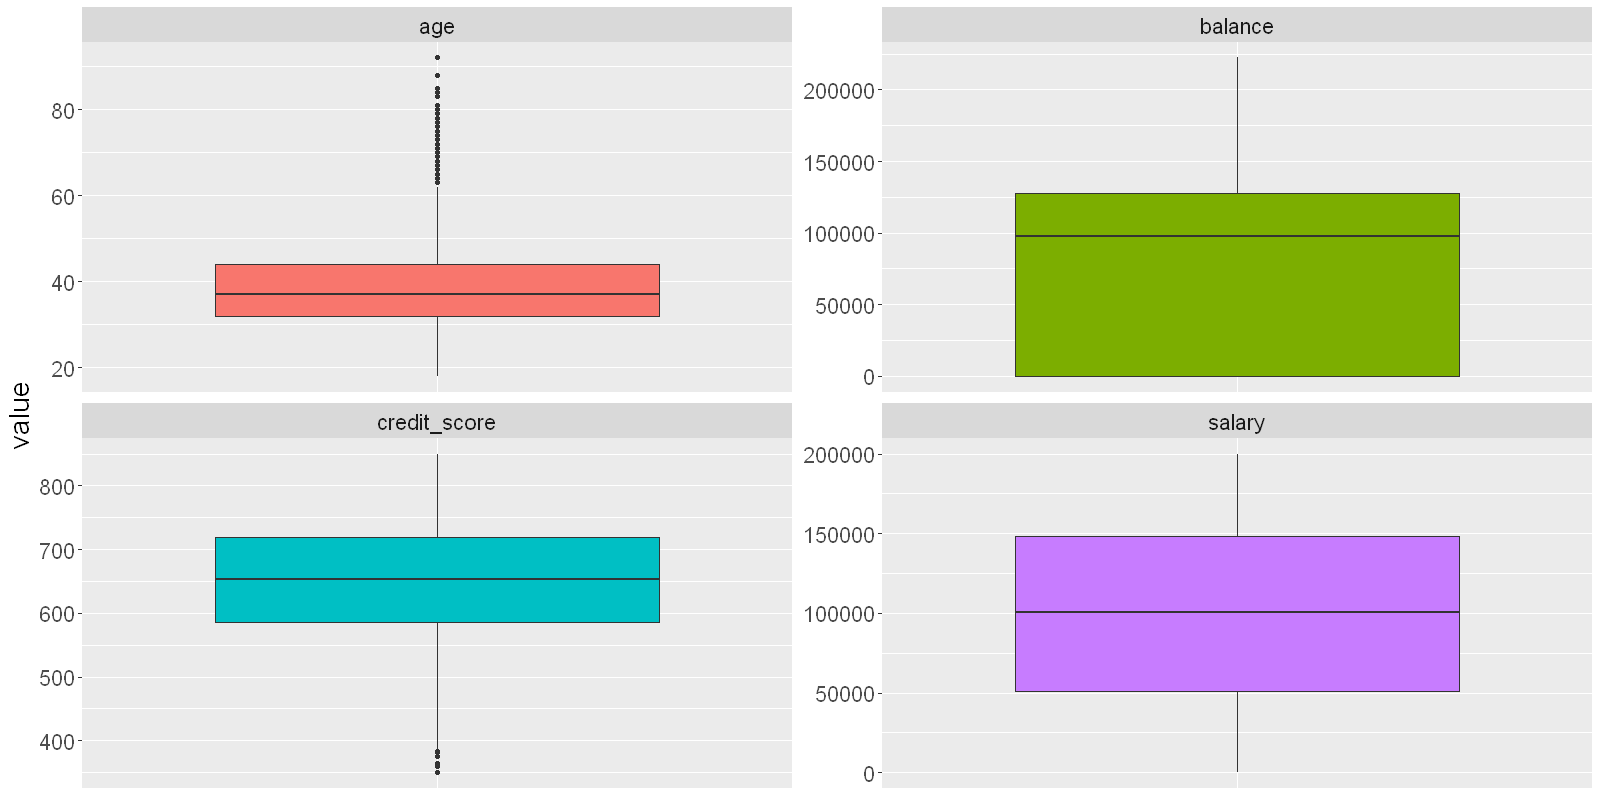

In [13]:
# Making the boxplot of numerical variable with the ggplot function
ggplot(df_long_num, aes(x = variable, y = value, fill = variable)) +
    geom_boxplot(notch = FALSE) +
    facet_wrap(~ variable, nrow = 2, scales = 'free') +
    guides(fill = 'none', alpha = 'none') +
    theme(text = element_text(size = 20),
        axis.title.x = element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

**Observations:**
- `age` and `credit_score` have **outliers**, but the outliers are not extreme and appear to be **natural variations** in the data. Thus, they can be ignored and no need for removal.
- When the outliers are excluded, the `age`, `credit_score`, and also `salary` columns show a **good symmetrical distribution**. This suggests that the data distribution is **well-balanced around the median**, with an even spread on both sides, indicating minimal skewness.
- Lastly, for the `balance` column we can see that it is **heavily left-skewed** as the distance between the first quartile and the media is large. Interestingly, notice that the first quartile is at zero. This might indicates that there are **a large number of zeros** in the column, which means there are significant number of accounts with **no balance**.

Next, we will see the detailed spread of the datapoints in the boxplot

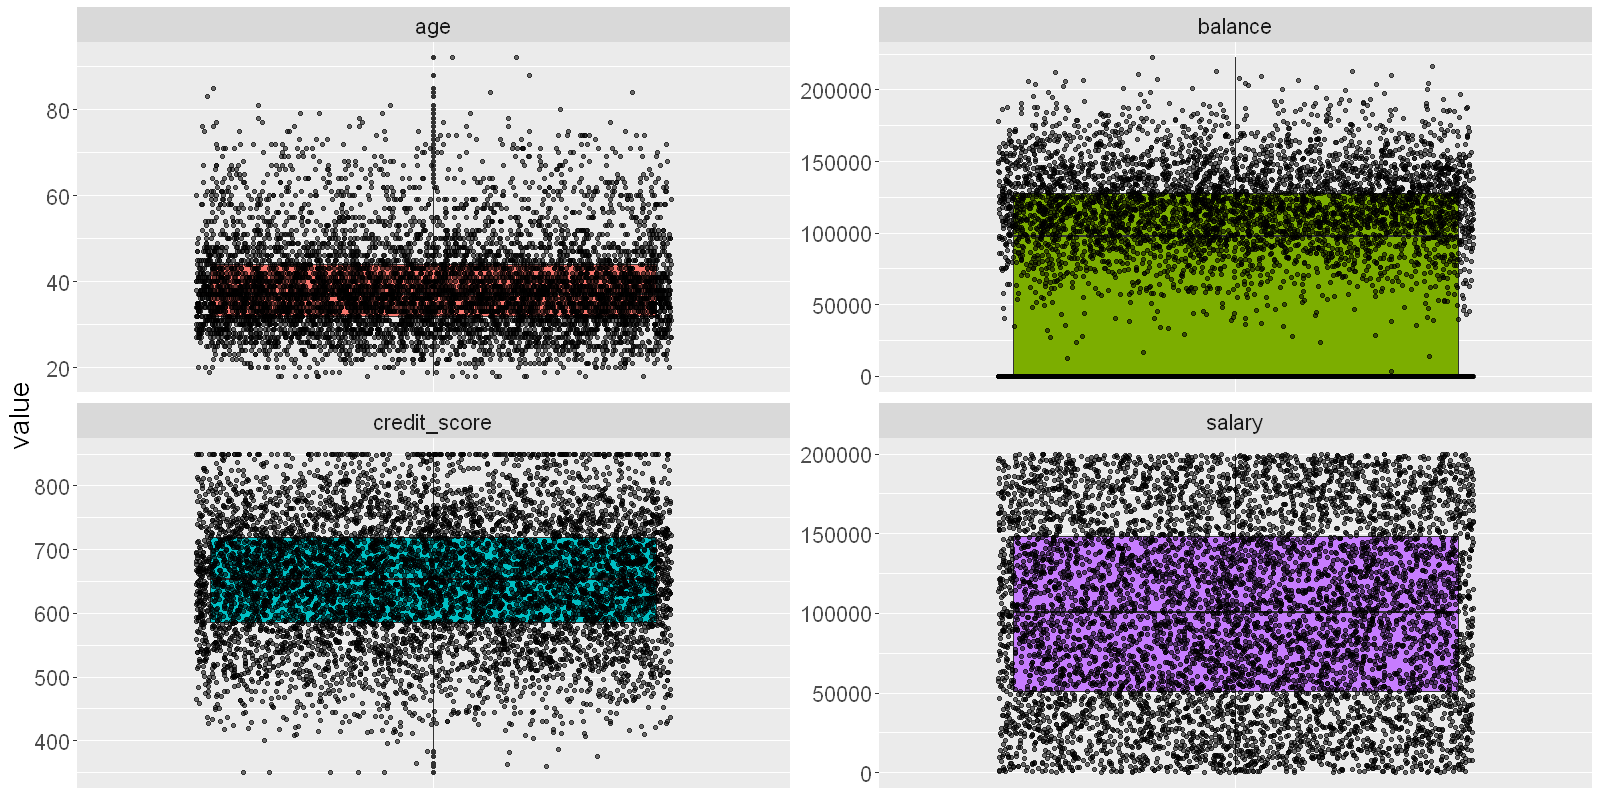

In [14]:
# Adding the data points to see the density of the datapoints of the boxplot
ggplot(df_long_num, aes(x = variable, y = value, fill = variable)) +
    geom_boxplot(notch = FALSE) +
    geom_jitter(aes(alpha = 0.6)) +
    facet_wrap(~ variable, nrow = 2, scales = 'free') +
    guides(fill = 'none', alpha = 'none') +
    theme(text = element_text(size = 20),
        axis.title.x = element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

**Observations:**
- The `age` column shows that while most of the data points are clustered around the center, there are still relatively large number of data point located above the center, suggesting the `age` distribution is **right-skewed**.
- For the `balance` column, as expected, there is **a significant cluster of zero values**. However, if we ignore the zeros, the spread of the remaining data points can be considered **centered around the median**, indicating a more balanced distribution among non-zero balances.
- For the `credit_score` column, the spread can also be considered **clustered around the center**, though there is also a **smaller cluster at the maximum value**. This cluster at the higher end is not as pronounced as in the `balance` column but is still noticable.
- Lastly, the `salary` column points displays an **evenly spread out** distribution, therefore this might suggests the salaries are **highly varied** among the customers in the datset.

Next we will plot the histogram and the QQ plot to see the distributions of the data

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


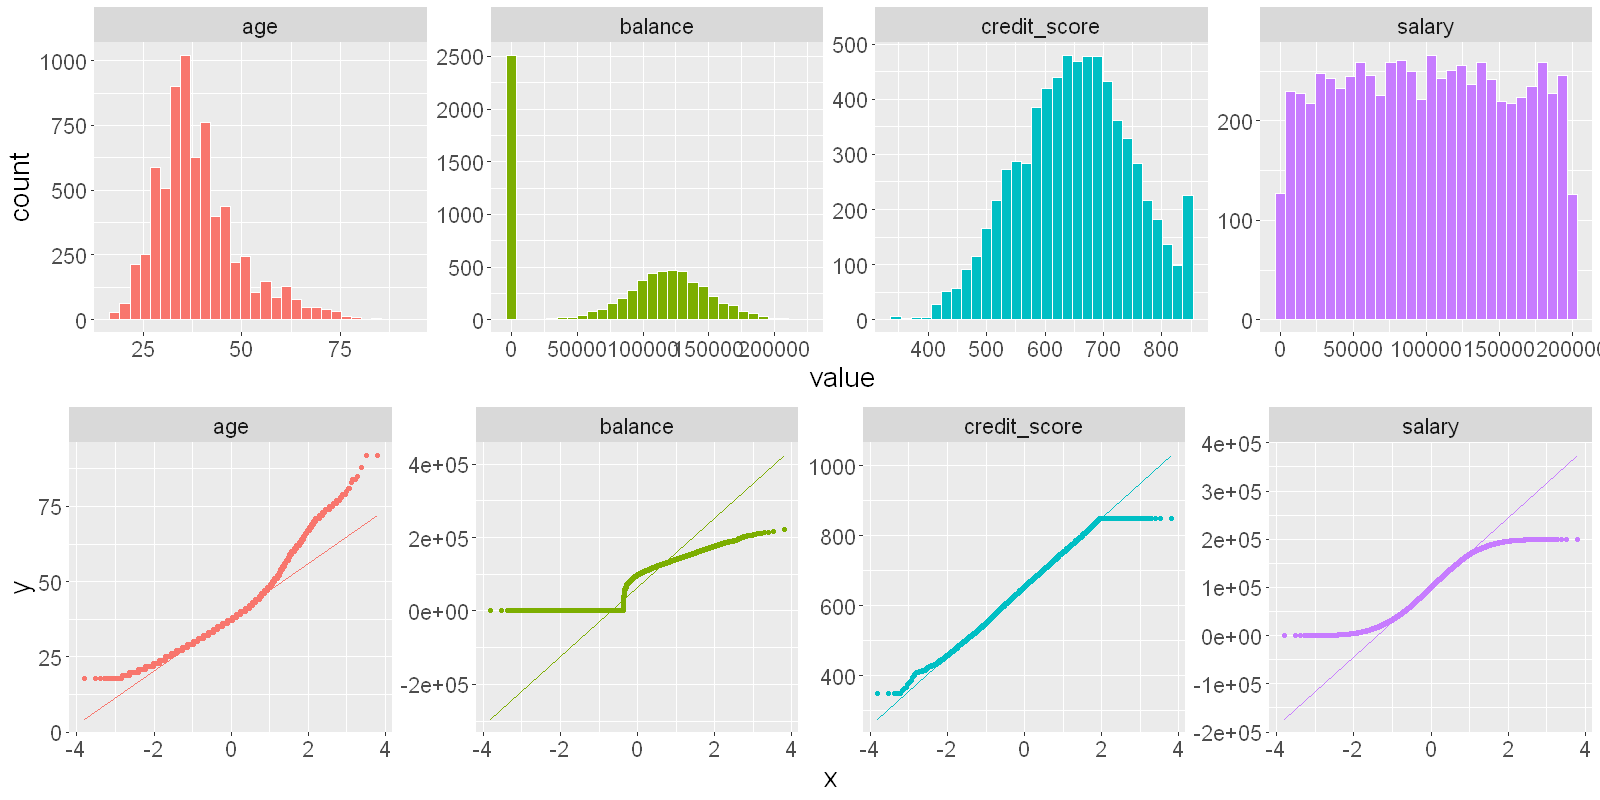

In [15]:
hist <- ggplot(df_long_num, aes(x = value, fill = variable)) +
    geom_histogram(color = 'white') +
    facet_wrap(~ variable, nrow = 1, scales = 'free') +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

qq <- ggplot(df_long_num, aes(sample = value, color = variable)) +
    geom_qq() +
    stat_qq() +
    stat_qq_line() +
    facet_wrap(~ variable, nrow = 1, scales = 'free') +
    guides(color = 'none') +
    theme(text = element_text(size = 20))

# Arrange the resulting plots into a grid
grid.arrange(hist, qq)

**Observations:**
- Most of the findings are aligned with the previously discussed from the boxplots.
- The `age` distribution is **skewed to the right**.
- The `balance` distribution has **two peaks**, which are for zero and non-zero balances. Note that the non-zero balances follows a **normal distribution**.
- The `credit_score` distribution also has **two peaks**, but not as extreme as the `balance` distribution. Here, the second peak is located at the maximum value. For the first peak, the distribution can be considered following a **normal distribution**.
- The `salary` column has a **uniform distribution** as the they are evenly spread out.
- Lastly, from the QQ plots, the `age` and `credit_score` columns have **light tails on the right side** as the deviations are not severe. On the other hand, the `balance` and `salary` have **heavy tails at both sides** as the deviations are severe.

### 2.2. Exploring the Categorical Columns

Next we will start to explore the categorical columns along with the `number_of_products` and `tenure` columns. For the categorical columns, we can simply just count the number of occurences for each category.

In [16]:
# Transforming the dataset to long format
df_long_cat <- df %>%
    mutate(number_of_products = factor(number_of_products),
           tenure = factor(tenure)) %>%
    pivot_longer(cols = c('number_of_products', 'has_credit_card', 'tenure', 'is_active_member', 'origin', 'gender'),
                names_to = 'variable', values_to = 'value')

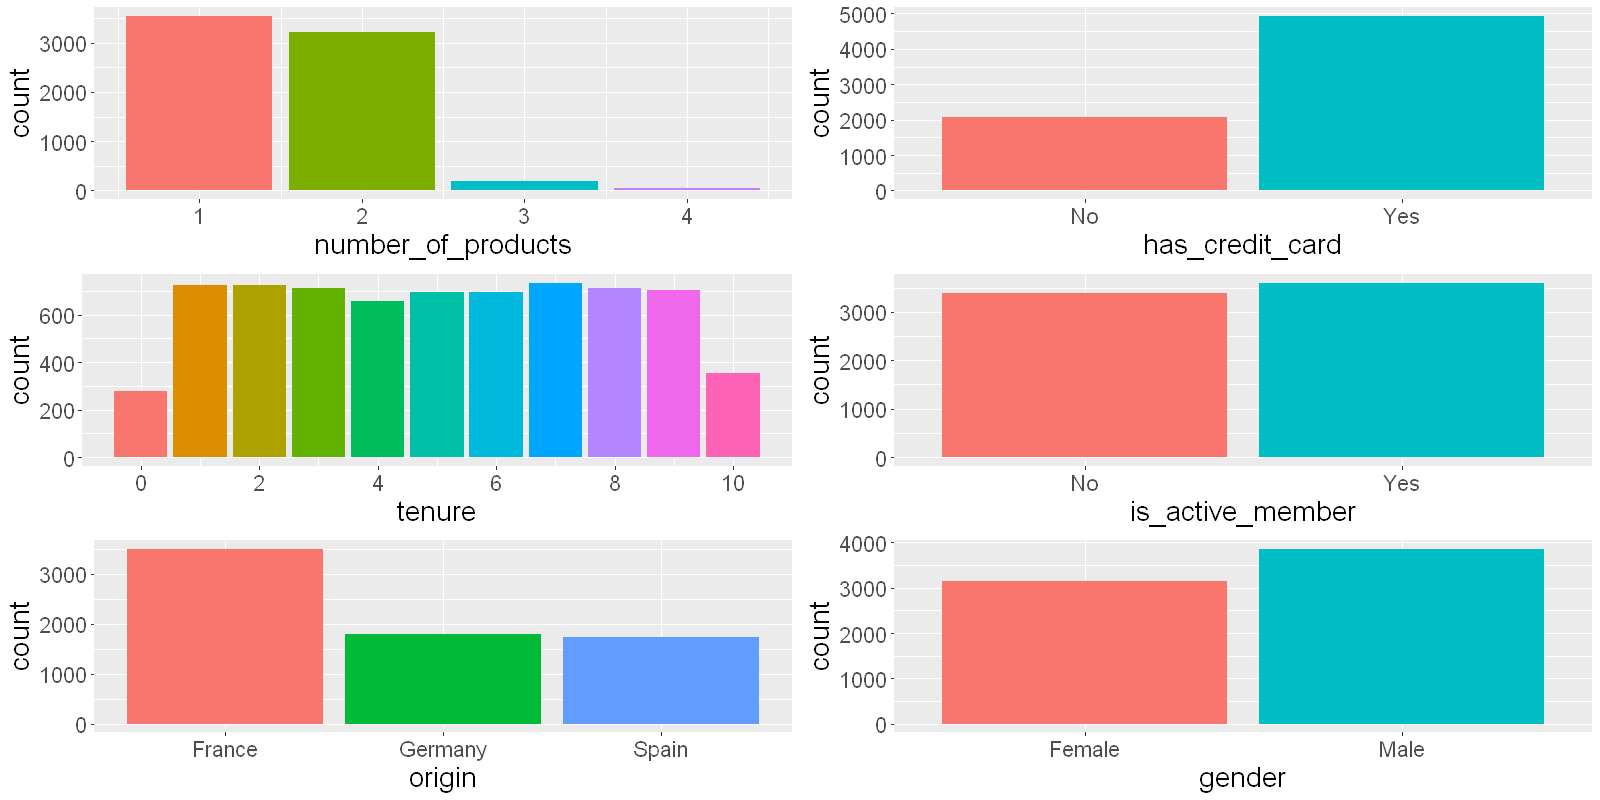

In [17]:
# Making barchart for each categorical variable
br1 <- ggplot(df, aes(x = number_of_products, fill = factor(number_of_products))) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

br2 <- ggplot(df, aes(x = has_credit_card, fill = has_credit_card)) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

br3 <- ggplot(df, aes(x = tenure, fill = factor(tenure))) +
    geom_bar() +
    scale_x_continuous(breaks = seq(0, 10, 2)) +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

br4 <- ggplot(df, aes(x = is_active_member, fill = is_active_member)) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

br5 <- ggplot(df, aes(x = origin, fill = origin)) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

br6 <- ggplot(df, aes(x = gender, fill = gender)) +
    geom_bar() +
    guides(fill = 'none') +
    theme(text = element_text(size = 20))

grid.arrange(br1, br2, br3, br4, br5, br6, nrow = 3)

**Observations:**
- From the `number_of_products`, it is clear that most customers only have **1 or 2 products** from the bank, while having **more than 2 products is really rare**.
- From the `tenure` column, it can be seen that the values are **evenly spread out between 1 to 9 years**, whereas **0 and 10 years are relatively rarer**.
- From the `origin`, it is evident that **most of the customers are coming from France**, whereas the number of customers from Germany and Spain are the same.
- Most of the customers also **have a credit card**, with the **ratio** between the number of customers that have a credit card and those who do not is around **1:2**.
- The number of active members is **slightly higher** than the inactive members seen from the `is_active_member` counts.
- Lastly, **most of the customers are male**, but the **difference** between the number of male and female customers are **not large**.

### 2.3. Correlation Analysis

 For the correlation analysis, we can start by making the correlation matrix to see if there's a correlation between the variables and then print the correlation value.

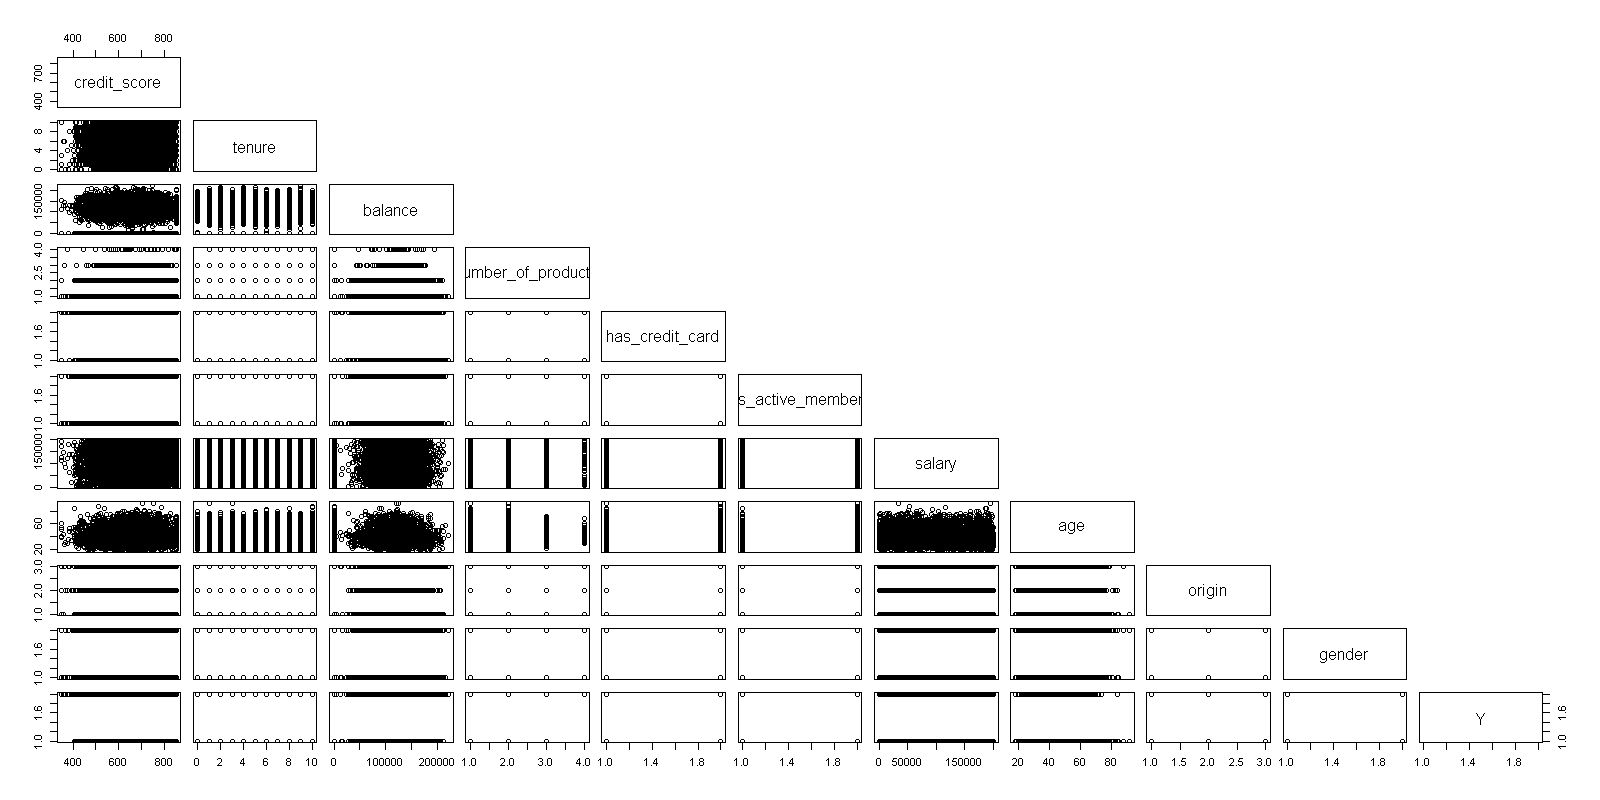

In [18]:
df %>%
    select(-ID) %>%
    pairs(upper.panel = NULL, cex.labels = 1.5)

In [19]:
df %>%
    select(-ID) %>%
    mutate_at(c('has_credit_card', 'is_active_member', 'origin', 'gender', 'Y'),
              as.numeric) %>%
    cor()

,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,age,origin,gender,Y
credit_score,1.0000000000,-0.008173098,0.020627628,0.006793626,-0.006769834,0.029578060,-0.004256482,0.004452970,0.0009544189,0.010228615,-0.026009470
tenure,-0.0081730984,1.000000000,-0.016646029,0.014660206,0.006853860,-0.048180200,-0.002434831,-0.009488312,0.0036657793,0.007939584,-0.014622679
balance,0.0206276278,-0.016646029,1.000000000,-0.297451097,-0.008207016,-0.014295621,0.005111364,0.017882013,0.0586550295,0.016495825,0.118911802
number_of_products,0.0067936256,0.014660206,-0.297451097,1.000000000,-0.007563155,0.016216234,0.026186090,-0.033607548,0.0090638013,-0.020558812,-0.050827528
has_credit_card,-0.0067698342,0.006853860,-0.008207016,-0.007563155,1.000000000,-0.004141486,-0.021307955,-0.011291702,-0.0136935064,0.002051649,-0.008738661
is_active_member,0.0295780598,-0.048180200,-0.014295621,0.016216234,-0.004141486,1.000000000,-0.015251559,0.096632069,0.0017733113,0.029089851,-0.147024374
salary,-0.0042564821,-0.002434831,0.005111364,0.026186090,-0.021307955,-0.015251559,1.000000000,-0.010034717,-0.0015174336,-0.006438099,0.002773081
age,0.0044529696,-0.009488312,0.017882013,-0.033607548,-0.011291702,0.096632069,-0.010034717,1.000000000,0.0172612033,-0.029988687,0.278600357
origin,0.0009544189,0.003665779,0.058655030,0.009063801,-0.013693506,0.001773311,-0.001517434,0.017261203,1.0000000000,0.001876656,0.040443892
gender,0.0102286151,0.007939584,0.016495825,-0.020558812,0.002051649,0.029089851,-0.006438099,-0.029988687,0.0018766563,1.000000000,-0.105864056


**Observations:**
- From the correlation matrix we can see that there are **no columns pairing that has significant correlation** between each other. This suggests that the columns are **independent** of each other.
- Interestingly, there is also **no variable** that has a **strong relationship with the target variable**.

Next we will make the density plot for both "Churn" and "Not Churn" in relation to several numerical columns to better visualize the distribution between the two labels in relation to the numerical columns.

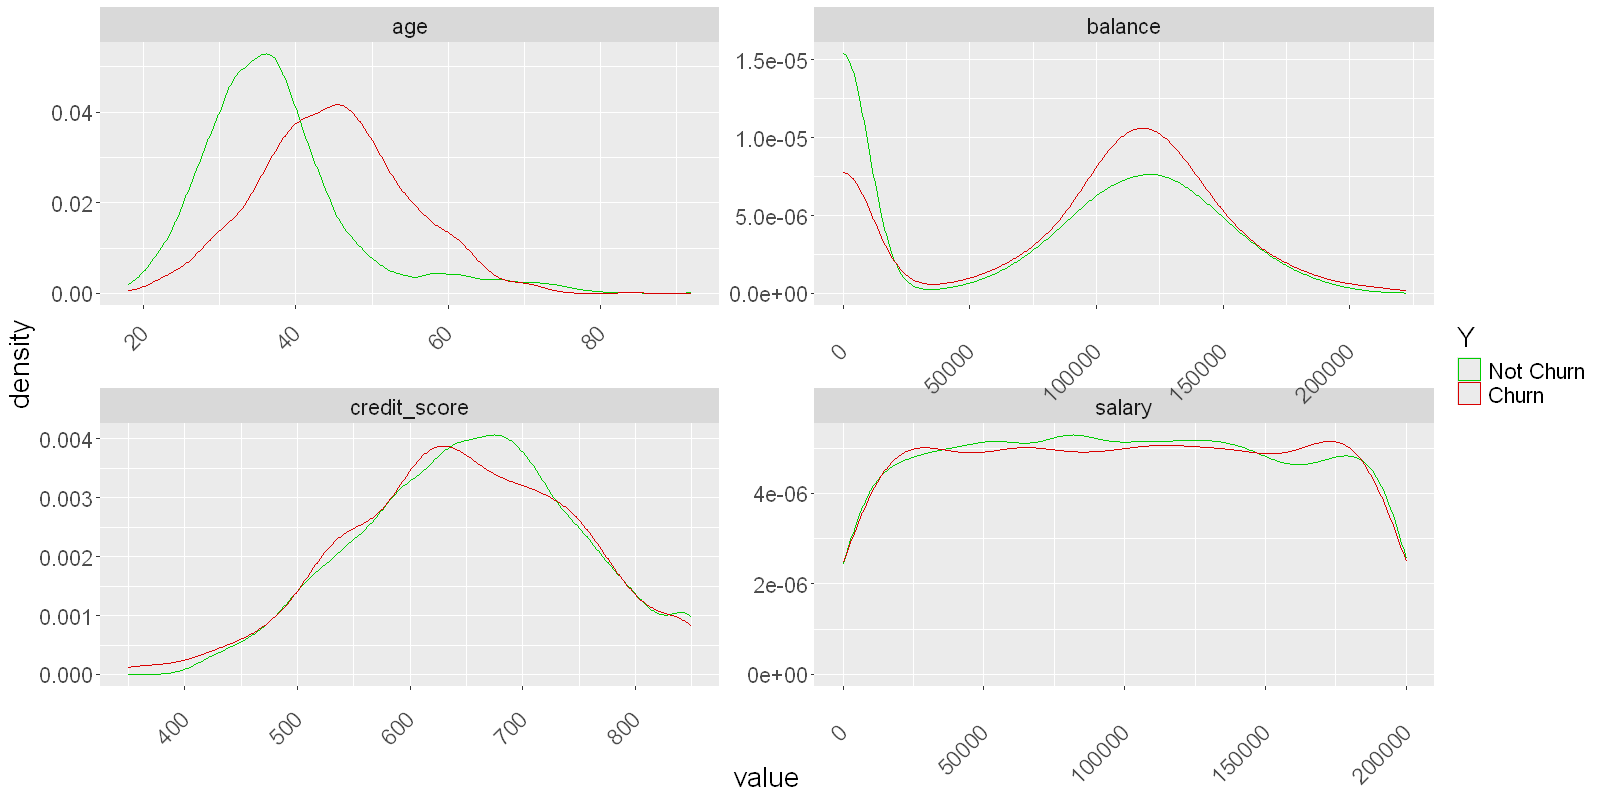

In [20]:
#Plotting the density plot in relation to the numerical variable
ggplot(df_long_num, aes(x = value, color = Y)) +
    geom_density() +
    facet_wrap(~ variable, nrow = 2, scales = 'free') +
    scale_color_manual(values = c('#00cd00', '#d80000')) +
    theme(text = element_text(size = 20),
          axis.text.x = element_text(angle = 45, vjust = 0.5, hjust=1))

**Observations:**
- In most of the density plots, except for `age` column, the two lines **overlaps** which signify that the columns **cannot clearly distinguish between the two classes**. This overlap suggests that these features may have limited capability to separate the classes.
- Interestingly, only with the `age` column shows **a noticable separation** between the two classes. Starting around the **age of 40**, the lines begin to diverge, indicating a potential class separation. However, the lines converge again around age 65. This notable separation in the `age` column suggests that it may have an **important role** when building a classification model as it can help differentiate between the two classes.

Next we'll plot the proportional barchart to evaluate the distribution of target variable for the categorical columns.

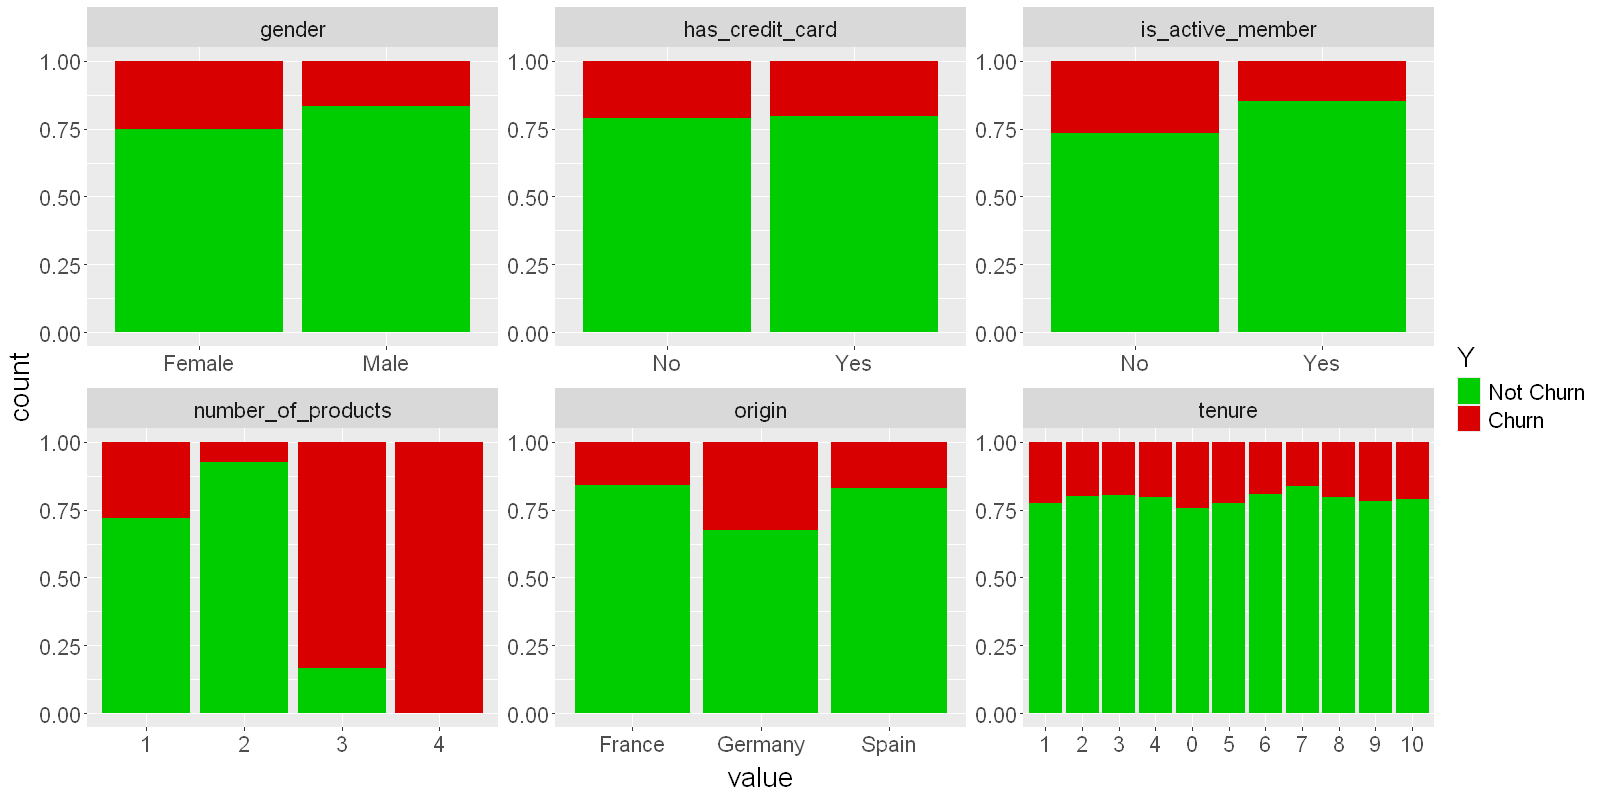

In [21]:
ggplot(df_long_cat, aes(x = value, fill = Y)) +
    geom_bar(position = position_fill(reverse = TRUE)) +
    scale_fill_manual(values = c('#00cd00', '#d80000')) +
    facet_wrap(~ variable, scales = 'free') +
    theme(text = element_text(size = 20))

**Observations:**
- For `gender`, it can be seen that **female customers** is slightly **more likely to churn** compared to male customers, however the difference is not significant.
- Whether having a credit card or not, it **does not affect** whether the customer will churn or not seen from the `has_credit_card` column.
- Similar to `gender`, **inactive members** is also **slighly more likely to churn** than active members seen from the `is_active_member` column, but the difference is also not significant.
- There are some interesting insights gained from from the `number_of_products` column. Here, we can see that if the customer has **more than 2 products**, there is an almost **100% chance that they will churn**. In contrast, if they have **exactly 2 products**, they are almost **100% unlikely to churn**. This suggests a clear distinction between the two classes, thus the `number_of_product` column has a **strong predictive capability** when we are building the classification model.
- For the `origin` column, similar to `gender` and `is_active_member`, customers from **Germany are more likely to churn** compared to customers from France and Spain. However, the difference is not significant.
- Lastly, for the `tenure` column, there is **no clear separation** between the values, as for every value, the **ratio is relatively the same**.

Next we will make several scatter plots to differentiate the two classes between the numerical columns to see the distribution of the labels in relation to those columns.

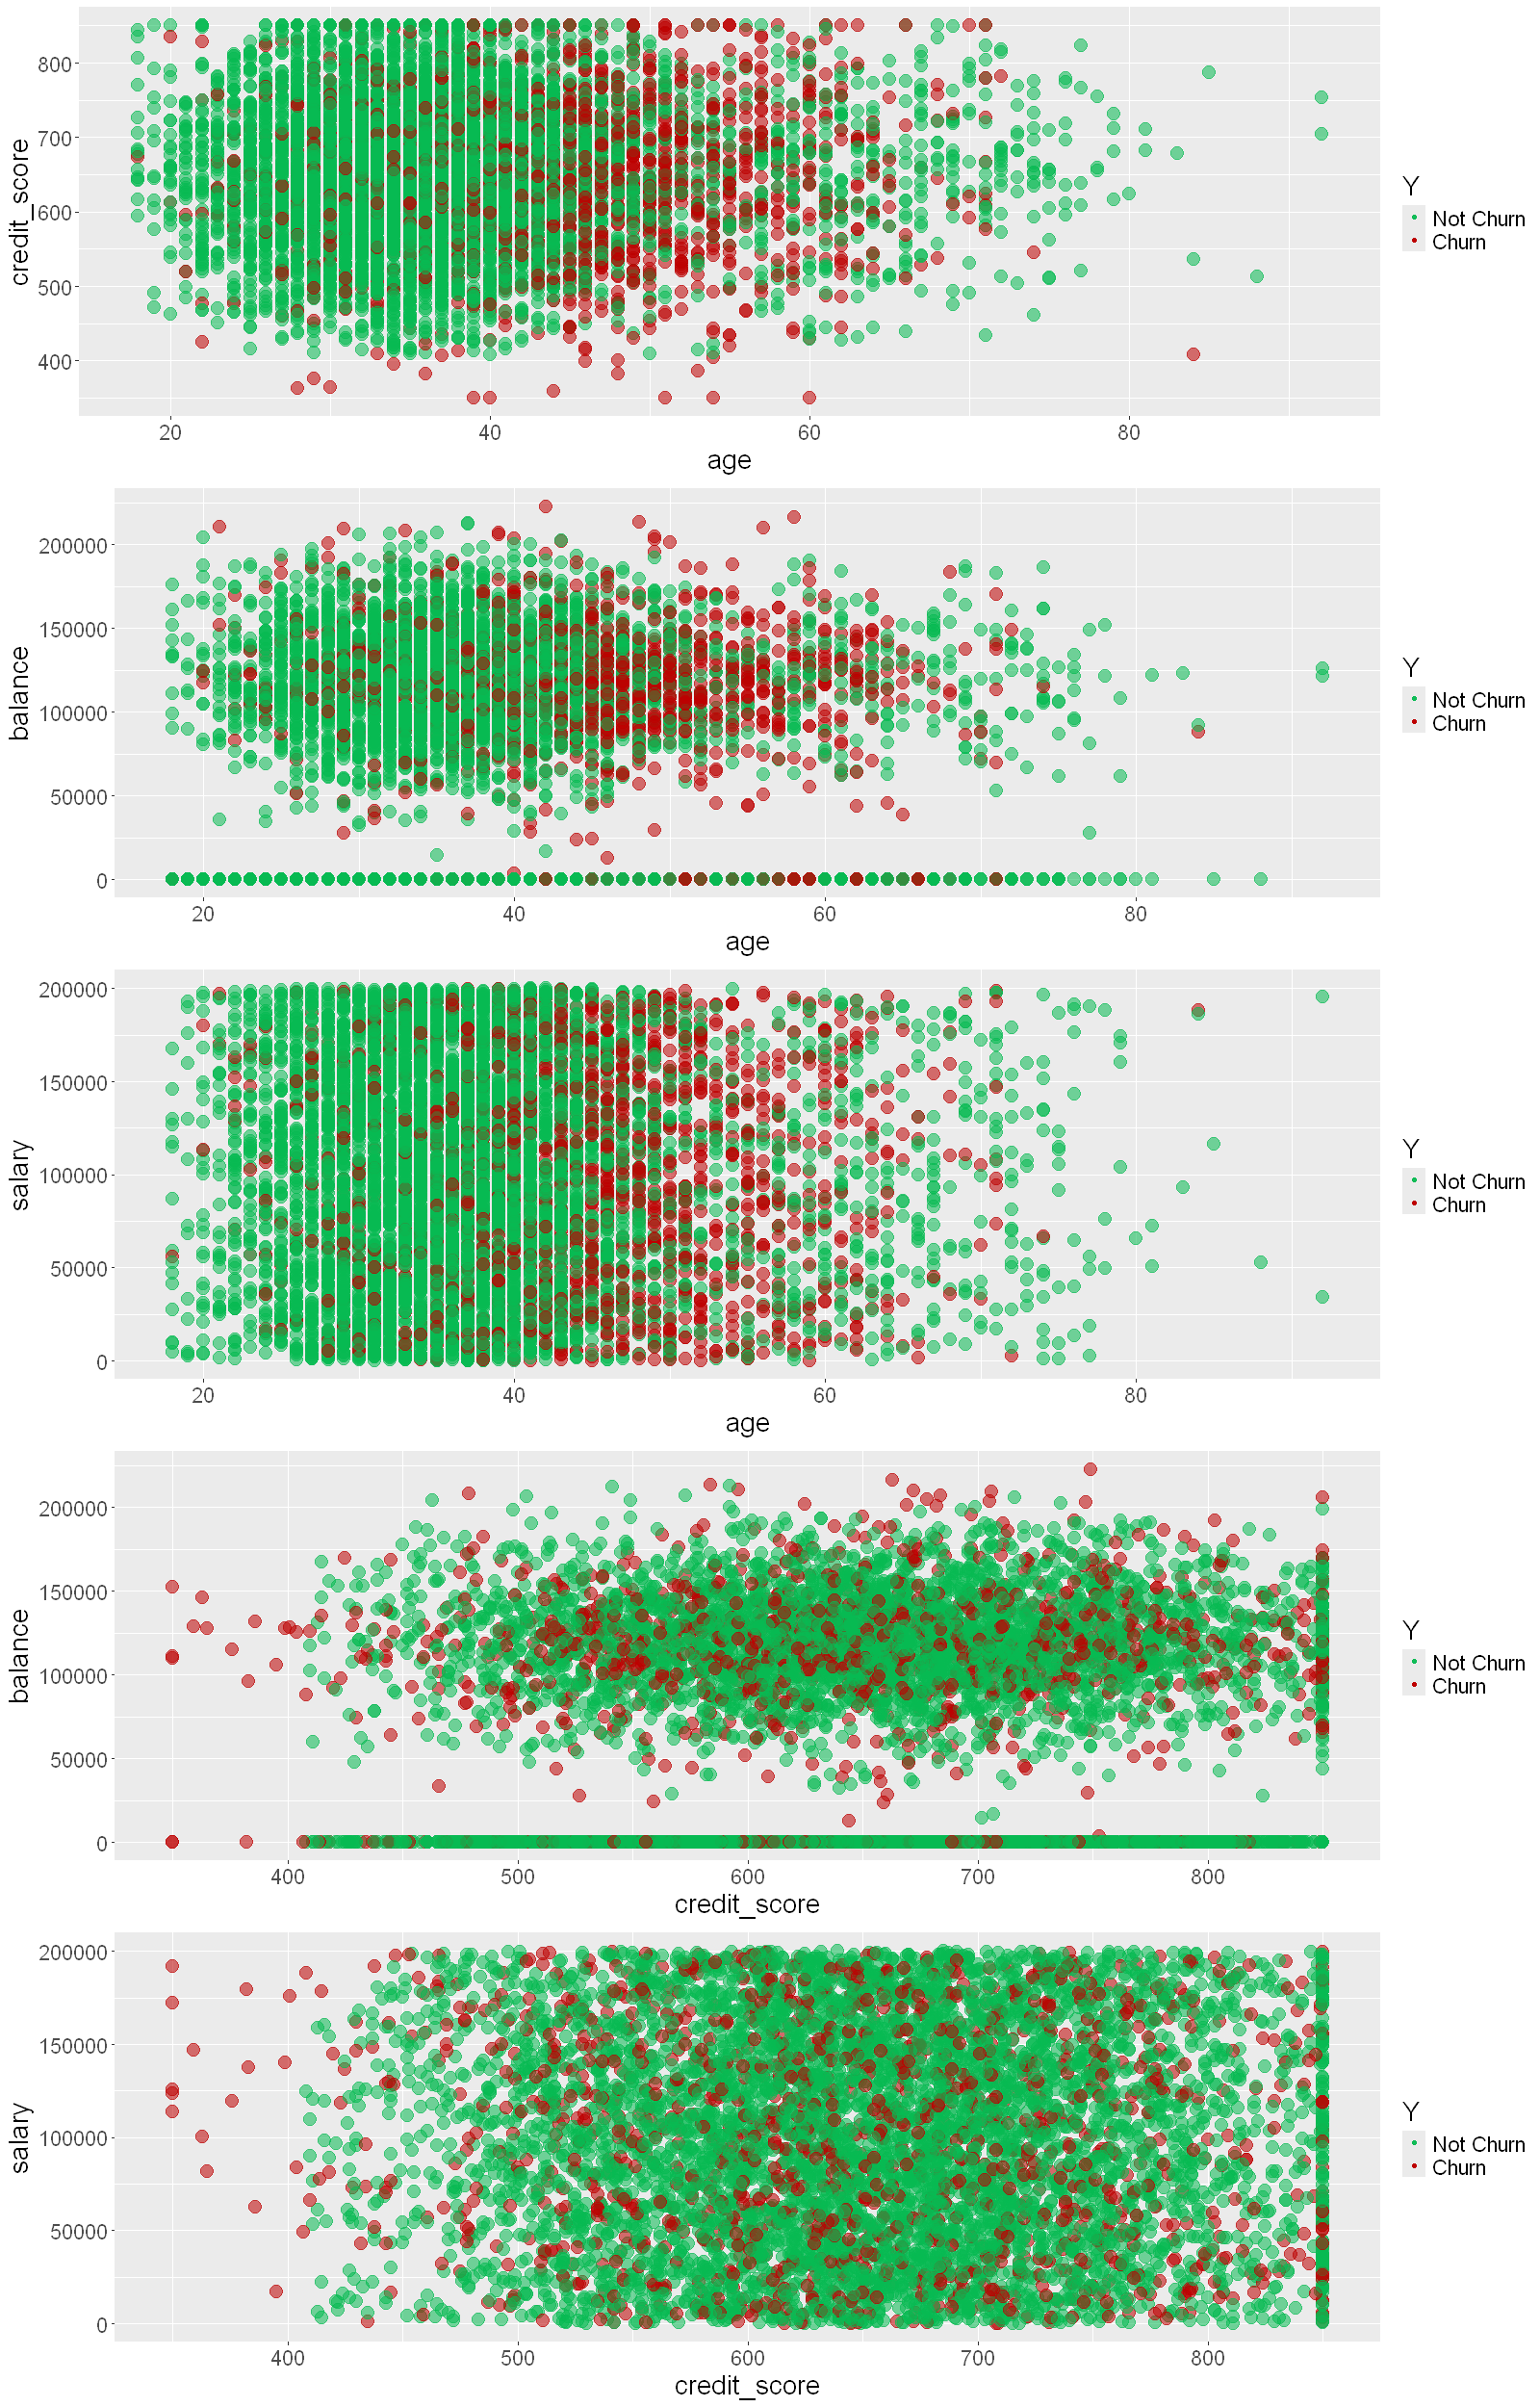

In [22]:
options(repr.plot.width = 16, repr.plot.height = 25, repr.plot.res = 100)

# Scatterplot for Age in relation to credit score, balance, and salary
sp1 <- ggplot(df, aes(x = age, y = credit_score, color = Y)) +
    geom_point(aes(size = 1.5, alpha = 1)) +
    scale_color_manual(values = c('#07ba52f3', '#bd0000')) +
    guides(size = 'none', alpha = 'none') +
    theme(text = element_text(size = 20))

sp2 <- ggplot(df, aes(x = age, y = balance, color = Y)) +
    geom_point(aes(size = 1.5, alpha = 1)) +
    scale_color_manual(values = c('#07ba52f3', '#bd0000')) +
    guides(size = 'none', alpha = 'none') +
    theme(text = element_text(size = 20))

sp3 <- ggplot(df, aes(x = age, y = salary, color = Y)) +
    geom_point(aes(size = 1.5, alpha = 1)) +
    scale_color_manual(values = c('#07ba52f3', '#bd0000')) +
    guides(size = 'none', alpha = 'none') +
    theme(text = element_text(size = 20))

sp4 <- ggplot(df, aes(x = credit_score, y = balance, color = Y)) +
    geom_point(aes(size = 1.5, alpha = 1)) +
    scale_color_manual(values = c('#07ba52f3', '#bd0000')) +
    guides(size = 'none', alpha = 'none') +
    theme(text = element_text(size = 20))

sp5 <- ggplot(df, aes(x = credit_score, y = salary, color = Y)) +
    geom_point(aes(size = 1.5, alpha = 1)) +
    scale_color_manual(values = c('#07ba52f3', '#bd0000')) +
    guides(size = 'none', alpha = 'none') +
    theme(text = element_text(size = 20))

grid.arrange(sp1, sp2, sp3, sp4, sp5, ncol= 1)

**Observations:**
- The `age` VS. `credit_score` plot reveals that all customers with **`credit_score` lower than 400 will churn**. Moreover, there are also a large number of customers that churn between the `age` of 40 to 60. We can also see that if the **`age` is above 40** and **`credit_score` above 800**, they are also **more likely to churn**.
- Next, the `age` VS. `balance` plot also have similar result in which the customers that churn are **concentrated at around the `age` of 40 - 60 years old**. We can also see that there are **more customers that churn** when their **`balance` has gone over 200,000**. There is also another interesting discovery that customers **older than 40** and have a **`balance` below 50,000 but not zero**, they are **more likely to churn**. Interestingly, customers with **zero balance** are **more unlikely to churn**.
- For the `age` VS. `salary` plot, we **did not found any interesting discovery**. We can only confirm that the **pattern of churn in relation with `age` is similar** with previous scatter plots as most of them is around 40 - 60 years old. Other than that, we can see that the data points are evenly spread out, similar to the distribution plot from the histogram.

**Note:**
- The `credit_score` VS. `salary` VS. `balance` plots are made to **visualize which customers that the bank do not want to lose**, which should be the ones in the upper right part of both plots. 
- We see here that although there are a lot of customers that did not churn in both plots, there are still some customers with **high `credit_score`, `balance`, or `salary` that churned**. `credit_score` is a metric to evaluate **how trustable** you are in the bank's eyes for them to lend money to you. Therefore, usually the bank would consider customers with **high `credit_score`** to be people that are **trustable and will not churn**, but in reality, there are still customers with high `credit_score` who churn and some of them even have a high `balance` or `salary`. These are the people who the bank did not want to lose.

## 3. Methodology<a class="anchor" id="sec_3"></a>

After doing the exploratory data analysis, let's start to design the model that will be built. The goal of this study is to **predict whether the customer will churn or not based on the given predictors**. The target variable for the prediction is represented by the `Y` column that contains two labels, "Churn" and "Not Churn". On the other there are 10 predictors that are going to be considered:
- credit_score
- tenure
- balance
- number_of_products
- has_credit_card
- is_active_member
- salary
- age
- origin
- gender

Before starting to build the model, please note that from the EDA section, we found out that the dataset has **an imbalance class problem**, as the "Not Churn" label has a much more count than the `Churn` label. Therefore, we nedd to apply a proper technique to handle this imbalance class problem. To address the problem, we can use **SMOTE (Synthetic Minority Over-sampling Technique)**. The SMOTE algorithm generates a new synthetic data by observing the pattern of the difference between a sample with its nearest neighbour, then adding the difference to the sample or just use the value from the sample.

Here, we will also test the models with and without applying the SMOTE technique to balance the class labels, to see whether the class imbalance really does affect the model performance or not.

Then, for the machine learning models, we will consider these five models:
- **Logistic Regression:** a linear model used for binary classification that estimates the probability of an event occurring based on input features.
- **Quadratic Discriminant Analysis (QDA):** a classification technique that models the decision boundary as a quadratic curve by assuming features have a normal distribution with class-specific covariance matrices.
- **Decision Tree:** a non-linear model that makes decisions by recursively splitting the data into subsets based on feature values, forming a tree-like structure.
- **Random Forest:** an ensemble learning method that combines multiple decision trees to improve classification accuracy and reduce overfitting.
- **Support Vector Machine (SVM):** a classification algorithm that finds the optimal hyperplane to separate different classes in the feature space by maximizing the margin between them.

To evaluate the performance of the models created, we consider **four key classification metrics:**
- **Accuracy:** measures how often the model correctly predicts the labels.
- **Precision:** the proportion of the predicted positive labels ("Churn") that are actually correct.
- **Recall:** the proportion of actual positive labels that the model successfully identifies.
- **F1 Score:** the harmonic mean of precision an recall, balancing both metrics.

Additionally considering the business case is about churning, a bank would risk losing a lot of money if there are a lot of undected customers that churn. Not to mention, a high number of churning rate can ruin the bank's reputation, which could also lead to a decrease in new customers coming. Therefore, we will put emphasis on the **recall** and **accuracy** as the most important metrics.

## 4. Model Selection <a class="anchor" id="sec_4"></a>

In this section we'll show the result of the evaluation for the model and compare their performances to decide which model is chosen as the final model. Please note that the in detail model development and evaluation are not given in this documentation.

**Without SMOTE**

|Model               | Accuracy | Precision | Recall | F1 Score |
|------------------- | -------- | --------- | ------ | -------- |
|Logistic Regression |  0.8042  |   0.5655  | 0.1907 |  0.2852  |
|QDA                 |  0.8304  |   0.6541  | 0.3651 |  0.4686  |
|Decision Tree       |  0.8594  |   0.7848  | 0.4325 |  0.5577  |
|Random Forest       |  0.8647  |   0.7786  | 0.4744 |  0.5896  |
|SVM (Radial Kernel) |  0.8585  |   0.8376  | 0.3837 |  0.5263  |

The evaluation results for the five classification models built using the original training data without applying SMOTE reveal some insights. Although all models show **good Accuracy scores**, all of them also show **poor Recall scores**, with none achieve a score above 0.5. Specifically, the Logistic Regression model has a particularly low F1 Score of 0.28, and the QDA model also does not exceed 0.5. Among all models, only Random Forests performs comparatively better with the highest F1 Score of 0.58, yet still does not surpass the 0.6 threshold.

These results are primarily caused by the **class imbalance** present within the dataset, which can lead to several issues:
- **Bias Toward Majority Class**: the models tend to favor the majority class, which in this case the "Not Churn", since it dominates the training data. This imbalance causes the model to predict most instances to the majority class, as it can result in inflated Accuracy scores, even though it fails to correctly identify the minority "Churn" class. This caused a phenomenon similar to **lazy model**, where minimal learning on the minority class occurs.
- **Poor Performance on the Minority Class**: due to minimal examples of the minority class ("Churn") during the training stage, the models will **struggle to correctly identify the minority class inistances**. This will lead to a high number of false negatives and consequently low Recall scores. This could lead to severe consequences if the business case requires precise identification to develop their strategies.

Among the models built, notably, the **Random Forest model performed better** compared to other models despite the class imbalance proble,. This is because Random Forest uses **bootstrapping**, in which each tree is trained with different subsets of the data. This approach inadvertently **increases the representation of the minority class** across various trees, thus making the model **much more sensitive** to the minority class compared to the other models.

Basing only from the model using imbalanced data, it is tempting to just utilize the Random Forest model. Nonetheless, let's frist see the results if we apply SMOTE to handle the class imbalance problem.

**With SMOTE**

|Model               | Accuracy | Precision | Recall | F1 Score |
|------------------- | -------- | --------- | ------ | -------- |
|Logistic Regression |  0.7203  |   0.3968  | 0.7023 |  0.5071  |
|QDA                 |  0.7499  |   0.4337  | 0.7232 |  0.5422  |
|Decision Tree       |  0.8218  |   0.5520  | 0.6907 |  0.6136  |
|Random Forest       |  0.8423  |   0.6098  | 0.6395 |  0.6243  |
|SVM (Radial Kernel) |  0.7908  |   0.4931  | 0.7488 |  0.5946  |

Here we have the result for all the models after the dataset class imbalance is dealt with using SMOTE. From the **Accuracy scores**, some method actually **performed worse** than the previous model counterpart. For example, the Logistic Regression, QDA, and SVM models **do not even reach 0.8** for the Accuracy scores. However, the Recall scores also become better with all of them having the scores above 0.7, but at the cost of the **Precision scores dropped down drastically**. This is due to the **Precision-Recall trade-off**. Although considering that with the previous model, except for SVM, the Logistic Regression and QDA's scores are still worse than this. Here, we can see that by solving the class imbalance, the Precision and Recall scores can actually get better. In addition, the **F1 Scores** for those three models also go over 0.5 which signifies a **better balance** between the Precision and Recall scores.

Compared to those three models, the D**ecision Tree and Random Forest models get a lot better**. Both of them have the Accuracy scores over 0.8, Precision over 0.55, and Recall over 0.6, with the **Decision Tree's Recall score almost reaching 0.7**. Their F1 Scores also pass 0.6, which are better than the previous models. Looking at the F1 Score alone, we see that **Random Forest has higher F1 Score** at 0.62, with a **more balanced Precision and Recall scores** at 0.60 and 0.63, respectively. The **Accuracy is also better** compared to the Decision Tree, so does this means that Random Forest is the suitable model for this customer churn case?

Considering that the business case we're dealing with here is **customer churn for banks**, we need to **consider the risk** that the bank will face if customers churn. The risk that the bank faces if their customers churn are:
- **Revenue Loss:** the most immediate risk caused from the loss of revenue from products and services that the customer used such as deposits, loans, credit cards, and investment accounts. This will be very impactful if the churned customer had a high lifetime value.
- **Impact on Profitability:** with a high churn rate, this signifies inefficiencies in the bank’s operations, such as poor customer service or inadequate product offerings. This could impact profitability of the bank in the long run
- **Reputation Risk:** caused from churned customer sharing their negative experience with others, in turn damaging the bank's reputation and making it harder to attract new customers.

From the EDA we done for the scatter plot between `age` and `balance` and between `age` and `credit_score`, we discover than some customers with high `balance` and `credit_score` are also prone to churning. These users are what the banks **hoped to retain** to prevent revenue loss and damage of reputation to the bank.

The banks would like to **accurately identify these users** and prevent them from churning, thus between the evaluation metrics, the **Recall score should be more valued**. This is because Recall is the metric that shows how many potential churner that we can identify. Correctly identifying a ustomer that potentially will churn can **greatly mitigate the bank risk**, especially if those users are high valued customer with high balance or salary and having high credit score.

Because of this, a model with high recall is prefered when compared to other metrics. From the models, we see that the **Decision Tree model has highest Recall score**, not the Random Forest. Looking at the other metric, Decision Tree also has good enough Precision (0.55), Accuracy (0.82), and well rounded F1 Score (0.61), which **aligns to the business case**. In addition, **Decision Tree also has a high interpretability level** compared to the Random Forest model. Each decision in **Decision Tree can be easily visualized and explained** to the general audience, compared to the Random Forest model that has hundreds of trees. **Decision Tree also does not have any complex aggregation process** that Random Forest has, which make it easier to understand. Due to above reason, **Decision Tree is chosen as the final model to be used**.

## 5. Model Development <a class="anchor" id="sec_5"></a>

In the previous section, we have decided to use a Decision Tree model as our final model to make the customer churn prediction. Therefore, in this section, we will start to develop the final model.

### 5.1. Data Preparation

From the previous section, it is clear that applying SMOTE to balance the class gives a better result than leaving the imbalance problem as it is. Thus, before starting to train the model, we need to apply SMOTE first to generate synthetic data.

In [23]:
# Remove the ID column
df <- df %>%
    select(-ID)

# Set seed for the random number generators
set.seed(370)

# Create the synthetic data
df_syn <- df %>%
  smotenc(var = 'Y', k = 5)

# Check the labels in the new dataset
summary(df_syn$Y)

Not Churn     Churn 
     5565      5565

### 5.2. Model Development

After dealing with the class imbalance problem, we can start to built the model. Note that here we will use a Decision Tree model with the splitting criteria using the Gini impurity.

In [24]:
# Set seed for the random number generator
set.seed(370)

# Start fitting the model
# Use Gini impurity as the splitting criteria
tree <- rpart(Y ~ ., data = df_syn, parms = list(split = "gini"))

## 6. Results and discussion <a class="anchor" id="sec_6"></a>

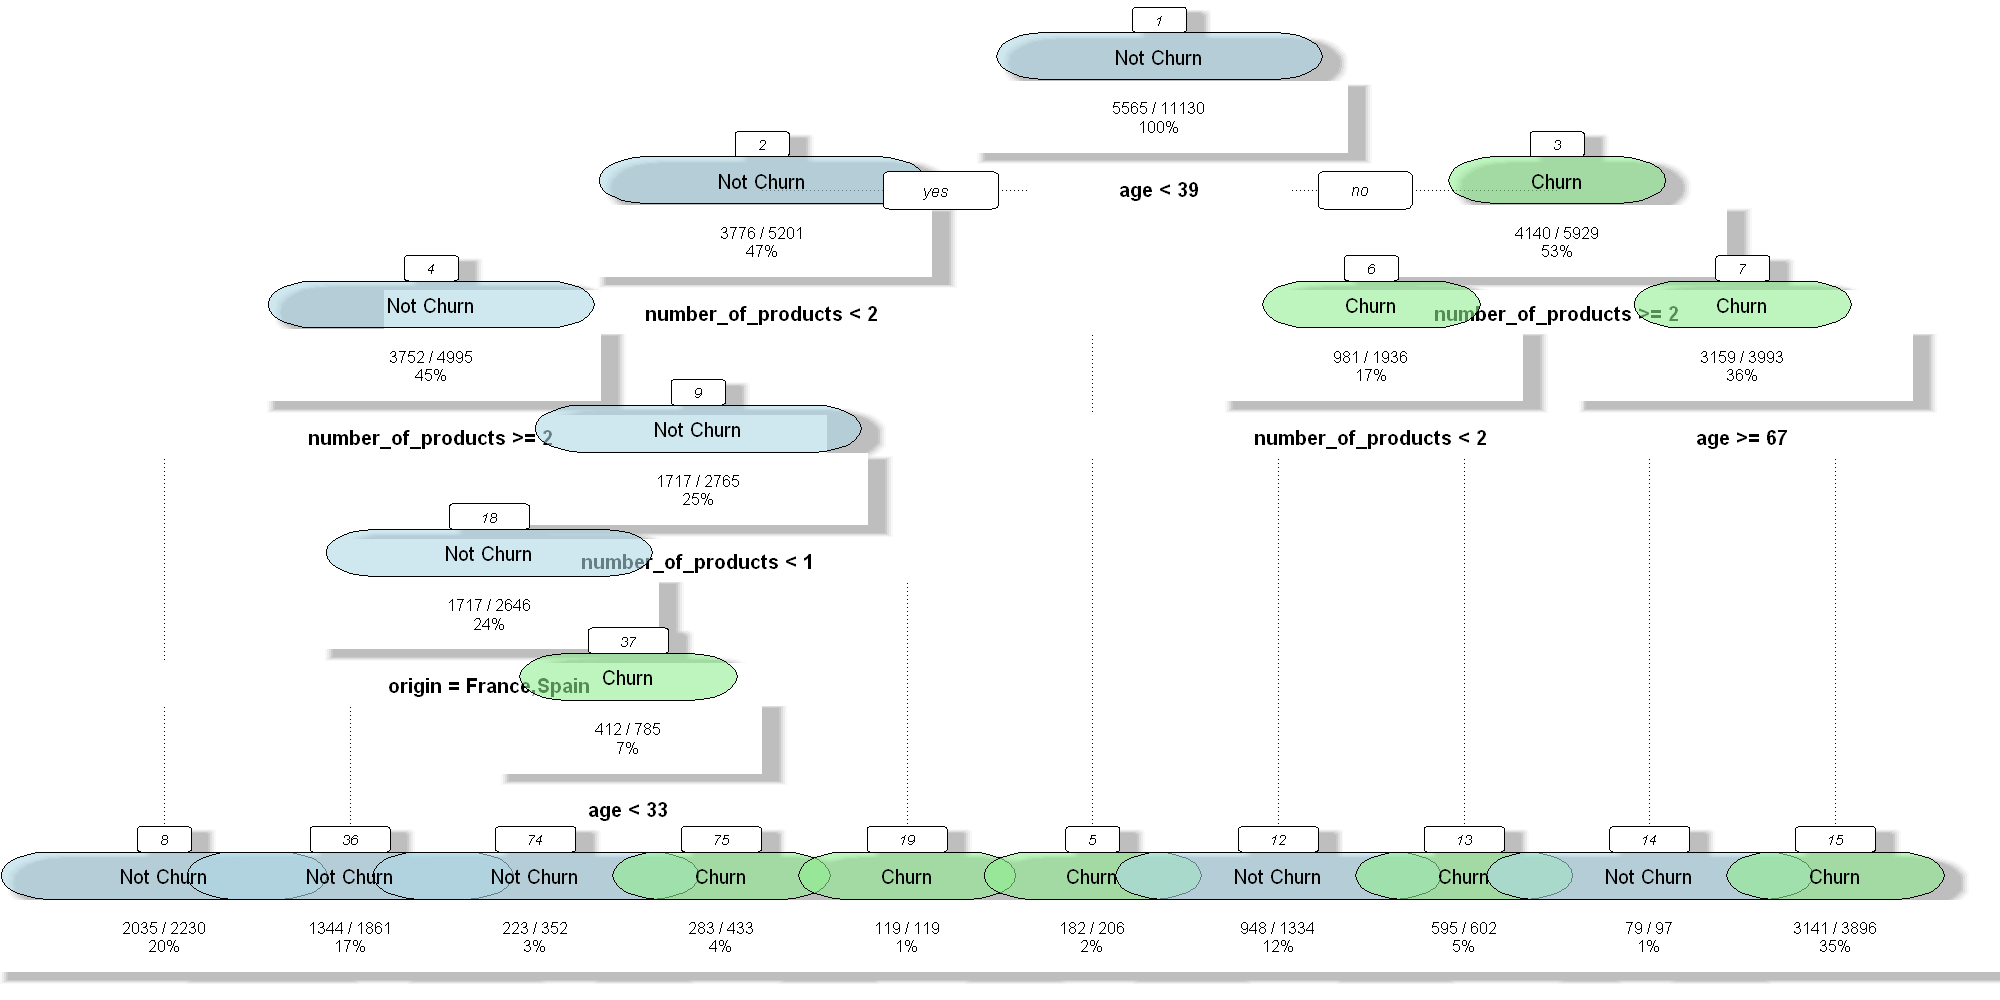

In [25]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)

# Adjusting color transparency using the rgb() function
transparent_blue <- rgb(173, 216, 230, max = 255, alpha = 150)  # Light blue with transparency
transparent_green <- rgb(144, 238, 144, max = 255, alpha = 150)  # Light green with transparency

# Plot the resulting Decision Tree
rpart.plot(tree,
           extra = 102,    # Display Gini or Entropy values
           box.palette = c(transparent_blue, transparent_green),  # Transparent box colors
           branch.lty = 3,  # Dashed lines connecting boxes
           fallen.leaves = TRUE,  # Display leaves horizontally
           faclen = 0,   # Adjust the length of factor labels
           under = TRUE, # Display text under terminal nodes
           shadow.col = "gray",  # Color of shadow under boxes
           nn = TRUE,    # Display node numbers
           yesno = TRUE, # Display "yes" and "no" for split decisions
           cex = 1.2)    # Adjust text size

Here we take a look at the important features in relation to the discoveries we made during the EDA process:
- As visualized with the scatterplot, **`age` does play an important role** for the Decision Tree, even becoming **the first split criteria**. This is consistent with the observation that a lot of customers around **40 to 60 years old churn**. We can also see that customers below 33 and above 67 years old are more likely to churn when looking at the deeper split. **This reinforces the importance of the age variable**.
- From the EDA, we also discover that the `number_of_product` column has a **clear distinction** between the customers that are more likely to churn or not. Here, we see that customers with the **`number_of_products` equal to or below 2 are more likely to not churn** while customers with the **`number_of_products` over 2 are more likely to churn**, confirming that **`number_of_products` is also another important factor**.
- The last factor used is the `origin` column. From the EDA section we see that the customers from Germany are more likely to churn, this also aligns with the split in the tree as customers **not originating from France or Spain are more likely to churn**.

## 7. Prediction<a class="anchor" id="sec_7"></a>

After training the model, we can use it to predict which customers in the unlabeled dataset are going to churn. First, we need to load and prepare the test data before using it for the prediction.

In [26]:
# Load the unlabeled dataset and pre-processed it like in training set
test <- read_csv('A2_customer_churn_submission.csv') %>%
    mutate(has_credit_card = factor(has_credit_card, levels = c(0,1), labels = c('No', 'Yes')),
           is_active_member = factor(is_active_member, levels = c(0,1), labels = c('No', 'Yes')),
           Y = factor(Y, levels = c(0,1), labels = c('Not Churn', 'Churn')),
           age = as.numeric(sub(".*\\bis an? (\\d+)-year-old.*", "\\1", customer_profile)),
           origin = factor(sub(".*\\bfrom ([A-Za-z]+).*", "\\1", customer_profile)),
           gender = factor(sub(".*\\b(male|female)\\b.*", "\\1", customer_profile), labels = c('Female', 'Male'))) %>%
    select(-Y, -customer_profile)

Rows: 990 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): customer_profile
dbl (9): ID, credit_score, tenure, balance, number_of_products, has_credit_c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


After that, we can start the prediction process and save the results.

In [27]:
# Add the prediction result to the dataframe
test['TARGET'] = predict(tree, test, type = 'class')

# Save the result into a CSV file
test %>%
  select(ID, TARGET) %>%
  mutate(TARGET = ifelse(TARGET == 'Churn', 1, 0)) %>%
  write_csv('pred_labels.csv')

## 8. Conclusion<a class="anchor" id="sec_7"></a>

From this project we concluded that **the most effective model** to be used for predicting whether or not a user will churn is a **Decision Tree** model. This is because Decision Tree has the **best Recall score** while also maintaining good score for the other evaluation metrics. Recall is important for customer churn prediction because the loss caused by a customer churn is quite high therefore a bank would prefer to accurately predict which customer would churn to make attempt to retain them as customer. In other words, **the cost for False Negatives are greater than the False Positives**, thus Recall is prefered over Precision and Accuracy. We also observed that among the 10 predictors used, the **most impactful predictors** used by the Decision Tree for making the splits are: **`age`**, **`number_of_products`**, and **`origin`**. We also highlighted how class imbalance can drastically decrease the model's performance indicating that **solving the class imbalance is the utmost importance** when making classification model.

## 9. References <a class="anchor" id="sec_8"></a>

- Haddadi, S. J., Farshidvard, A., Silva, F. D. S., Reis, J. C. D., & Da Silva Reis, M. (2024). Customer churn prediction in imbalanced datasets with resampling methods: A comparative study. Expert Systems With Applications, 246, 123086. https://doi.org/10.1016/j.eswa.2023.123086
- Huilgol, P. (2024, January 15). Accuracy vs. F1-score. Medium. https://medium.com/analytics-vidhya/accuracy-vs-f1-score-6258237beca2 
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer. 
- Maklin, C. (2022, May 14). Synthetic minority over-sampling technique (smote). Medium. https://medium.com/@corymaklin/synthetic-minority-over-sampling-technique-smote-7d419696b88c 
- Singh, P. P., Anik, F. I., Senapati, R., Sinha, A., Sakib, N., & Hossain, E. (2024). Investigating customer churn in banking: A machine learning approach and visualization app for data science and management. Data Science and Management, 7(1), 7–16. https://doi.org/10.1016/j.dsm.2023.09.002
- Vidalwadi, V. (2023, February 15). Accuracy, precision, recall, F1 score, loss, and applications of machine learning: Learning as I learn. Medium. https://medium.com/@vidalwadi11/accuracy-precision-recall-f1-score-loss-and-applications-of-machine-learning-learning-as-i-c6b1720e09d9 
